# experiments: popularity baseline vs ALS

This notebook compares a simple popularity baseline vs ALS for cart-oriented recsys.

Evaluation protocol:
- train: all interactions before the last N days
- test: add-to-cart events in the last N days
- sessions: a new session starts after a 4-hour inactivity gap
- only sessions with at least 2 items are used
- cart context = session[:-1]
- target item = session[-1]

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from implicit.als import AlternatingLeastSquares

os.environ.pop("MPLBACKEND", None)

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cart_driven_recsys.config import cfg
from cart_driven_recsys.covisit import build_covisit_index, recommend_with_covisit
from cart_driven_recsys.train import (
    build_interaction_matrix,
    build_item_popularity_ranking,
    evaluate_recommender,
    load_raw_addtocart_events,
    load_weighted_events,
    recommend_with_als,
    recommend_with_popularity,
    sample_sessions,
    split_by_time,
    train_als_model,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4)

evaluation_k = cfg.s.eval_k
random_seed = 42

/home/mle-user/mle_projects/cart-driven-recsys/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
weighted_events_dataframe = load_weighted_events()

print(f"weighted events: {len(weighted_events_dataframe):,}")
print(f"users: {weighted_events_dataframe['user_id'].nunique():,}")
print(f"items: {weighted_events_dataframe['item_id'].nunique():,}")
print(
    f"event time range: "
    f"{weighted_events_dataframe['event_time'].min()} -> "
    f"{weighted_events_dataframe['event_time'].max()}"
)

weighted_events_dataframe.head()

weighted events: 2,756,101
users: 1,407,580
items: 235,061
event time range: 2015-05-03 03:00:04.384000+00:00 -> 2015-09-18 02:59:47.788000+00:00


,user_id,item_id,event_time,weight
0,241793,287090,2015-05-03 05:45:20.036000+00:00,1.0
1,1206788,116444,2015-05-03 05:24:11.248000+00:00,1.0
2,624610,362372,2015-05-03 05:26:57.282000+00:00,1.0
3,1407102,454806,2015-05-03 05:20:50.987000+00:00,1.0
4,283409,262826,2015-05-03 05:17:00.903000+00:00,1.0


In [3]:
train_interactions_dataframe, test_events_dataframe, cutoff_timestamp = split_by_time(
    weighted_events_dataframe=weighted_events_dataframe,
    test_days=cfg.s.eval_test_days,
)

interaction_matrix, user_ids, item_ids = build_interaction_matrix(
    train_interactions_dataframe
)

item_popularity_ranking = build_item_popularity_ranking(train_interactions_dataframe)

raw_addtocart_events_dataframe = load_raw_addtocart_events()
train_addtocart_events_dataframe = raw_addtocart_events_dataframe[
    raw_addtocart_events_dataframe["event_time"] < cutoff_timestamp
].copy()

sampled_sessions = sample_sessions(
    test_events_dataframe=test_events_dataframe,
    gap_hours=cfg.s.eval_session_gap_hours,
    n_sessions=cfg.s.eval_n_sessions,
    random_seed=random_seed,
)

matrix_density = interaction_matrix.nnz / (
    interaction_matrix.shape[0] * interaction_matrix.shape[1]
)

print(f"cutoff date: {cutoff_timestamp.date()}")
print(f"train interactions: {len(train_interactions_dataframe):,}")
print(f"train add-to-cart events: {len(train_addtocart_events_dataframe):,}")
print(f"test add-to-cart events: {len(test_events_dataframe):,}")
print(f"sampled sessions: {len(sampled_sessions):,}")
print(
    f"matrix shape: "
    f"{interaction_matrix.shape[0]:,} users × {interaction_matrix.shape[1]:,} items"
)
print(f"non-zero entries: {interaction_matrix.nnz:,}")
print(f"density: {matrix_density:.6%}")
print(f"top-10 train popular items: {item_popularity_ranking[:10]}")

cutoff date: 2015-08-19
train interactions: 1,727,867
train add-to-cart events: 55,482
test add-to-cart events: 13,850
sampled sessions: 1,992
matrix shape: 1,133,422 users × 213,717 items
non-zero entries: 1,727,867
density: 0.000713%
top-10 train popular items: [461686, 257040, 5411, 7943, 309778, 187946, 48030, 312728, 369447, 29196]


In [4]:
popularity_metrics = evaluate_recommender(
    recommend_function=lambda cart_item_ids, k: recommend_with_popularity(
        item_popularity_ranking=item_popularity_ranking,
        cart_item_ids=cart_item_ids,
        k=k,
    ),
    sampled_sessions=sampled_sessions,
    item_catalog_ids=item_ids,
    item_popularity_ranking=item_popularity_ranking,
    k=evaluation_k,
)

print("popularity baseline metrics:")
for metric_name, metric_value in popularity_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

popularity baseline metrics:
hit@10: 0.0050
ndcg@10: 0.0044
coverage@10: 0.0001
popularity_bias_top_1pct: 1.0000
n_sessions: 1992


In [5]:
als_model = train_als_model(interaction_matrix)

item_id_to_index = {
    int(item_id): item_index
    for item_index, item_id in enumerate(item_ids)
}

als_metrics = evaluate_recommender(
    recommend_function=lambda cart_item_ids, k: recommend_with_als(
        model=als_model,
        item_ids=item_ids,
        item_id_to_index=item_id_to_index,
        cart_item_ids=cart_item_ids,
        k=k,
    ),
    sampled_sessions=sampled_sessions,
    item_catalog_ids=item_ids,
    item_popularity_ranking=item_popularity_ranking,
    k=evaluation_k,
)

print("ALS metrics:")
for metric_name, metric_value in als_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

/home/mle-user/mle_projects/cart-driven-recsys/.venv/lib/python3.12/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 30/30 [03:24<00:00,  6.83s/it, loss=0.00025] 


ALS metrics:
hit@10: 0.0562
ndcg@10: 0.0333
coverage@10: 0.0105
popularity_bias_top_1pct: 0.2949
n_sessions: 1992


In [6]:
covisit_index = build_covisit_index(
    train_events_dataframe=train_addtocart_events_dataframe,
    gap_hours=cfg.s.eval_session_gap_hours,
    top_neighbors_per_item=200,
)

print(f"covisit source items: {len(covisit_index):,}")

covisit source items: 13,310


In [7]:
covisit_metrics = evaluate_recommender(
    recommend_function=lambda cart_item_ids, k: recommend_with_covisit(
        covisit_index=covisit_index,
        cart_item_ids=cart_item_ids,
        k=k,
        fallback_item_ids=item_popularity_ranking,
    ),
    sampled_sessions=sampled_sessions,
    item_catalog_ids=item_ids,
    item_popularity_ranking=item_popularity_ranking,
    k=evaluation_k,
)

print("co-visitation metrics:")
for metric_name, metric_value in covisit_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

co-visitation metrics:
hit@10: 0.0467
ndcg@10: 0.0325
coverage@10: 0.0222
popularity_bias_top_1pct: 0.6679
n_sessions: 1992


In [8]:
comparison_dataframe = pd.DataFrame(
    [
        {"model": "popularity", **popularity_metrics},
        {"model": "als", **als_metrics},
        {"model": "co_visitation", **covisit_metrics},
    ]
).set_index("model")

comparison_dataframe

,hit@10,ndcg@10,coverage@10,popularity_bias_top_1pct,n_sessions
model,,,,,
popularity,0.005020,0.004391,0.000051,1.000000,1992
als,0.056225,0.033311,0.010533,0.294909,1992
co_visitation,0.046687,0.032544,0.022160,0.667922,1992


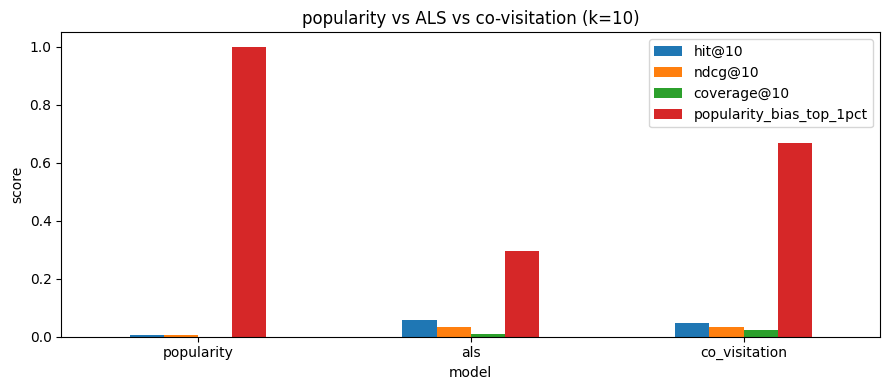

In [9]:
score_columns = [
    f"hit@{evaluation_k}",
    f"ndcg@{evaluation_k}",
    f"coverage@{evaluation_k}",
    "popularity_bias_top_1pct",
]

comparison_dataframe[score_columns].plot(kind="bar", rot=0)
plt.title(f"popularity vs ALS vs co-visitation (k={evaluation_k})")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [10]:
factor_results: list[dict[str, float | int]] = []

for factor_count in [16, 32, 64, 128]:
    candidate_model = AlternatingLeastSquares(
        factors=factor_count,
        iterations=cfg.s.als_iterations,
        regularization=cfg.s.als_regularization,
        alpha=cfg.s.als_alpha,
        use_gpu=False,
        calculate_training_loss=True,
        random_state=42,
    )

    candidate_model.fit(interaction_matrix)

    candidate_item_id_to_index = {
        int(item_id): item_index
        for item_index, item_id in enumerate(item_ids)
    }

    candidate_metrics = evaluate_recommender(
        recommend_function=lambda cart_item_ids, k, model=candidate_model, item_id_to_index=candidate_item_id_to_index: recommend_with_als(
            model=model,
            item_ids=item_ids,
            item_id_to_index=item_id_to_index,
            cart_item_ids=cart_item_ids,
            k=k,
        ),
        sampled_sessions=sampled_sessions,
        item_catalog_ids=item_ids,
        item_popularity_ranking=item_popularity_ranking,
        k=evaluation_k,
    )

    factor_results.append(
        {
            "factors": factor_count,
            **candidate_metrics,
        }
    )

factor_results_dataframe = pd.DataFrame(factor_results).set_index("factors")
factor_results_dataframe

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [03:25<00:00,  6.85s/it, loss=0.00025] 


,hit@10,ndcg@10,coverage@10,popularity_bias_top_1pct,n_sessions
factors,,,,,
16,0.033635,0.018867,0.003762,0.993299,1992
32,0.048193,0.027007,0.006321,0.973610,1992
64,0.060241,0.035275,0.010724,0.850597,1992
128,0.056225,0.033311,0.010533,0.294909,1992


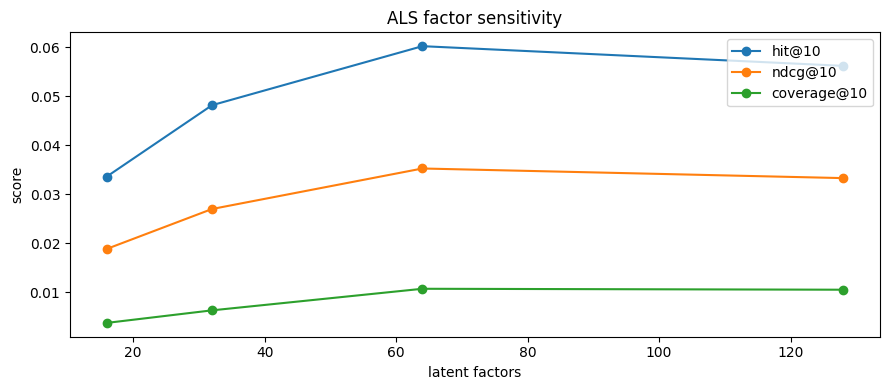

In [11]:
factor_results_dataframe[
    [f"hit@{evaluation_k}", f"ndcg@{evaluation_k}", f"coverage@{evaluation_k}"]
].plot(marker="o")
plt.title("ALS factor sensitivity")
plt.xlabel("latent factors")
plt.ylabel("score")
plt.tight_layout()
plt.show()

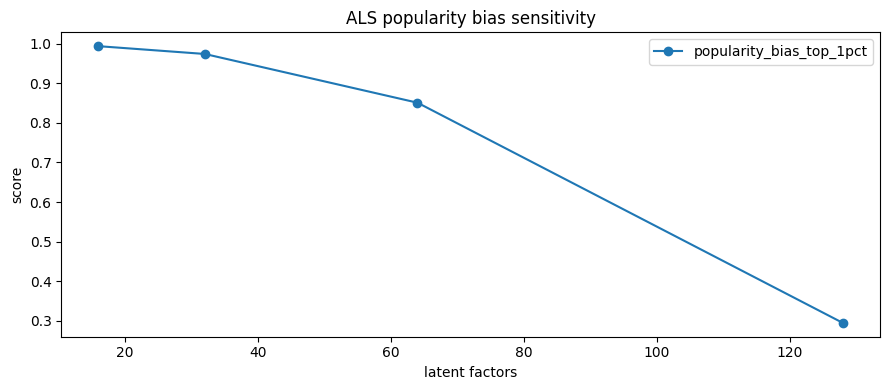

In [12]:
factor_results_dataframe[["popularity_bias_top_1pct"]].plot(marker="o")
plt.title("ALS popularity bias sensitivity")
plt.xlabel("latent factors")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [13]:
covisit_results: list[dict[str, float | int]] = []

for top_neighbors_per_item in [50, 100, 200, 400]:
    candidate_covisit_index = build_covisit_index(
        train_events_dataframe=train_addtocart_events_dataframe,
        gap_hours=cfg.s.eval_session_gap_hours,
        top_neighbors_per_item=top_neighbors_per_item,
    )

    candidate_metrics = evaluate_recommender(
        recommend_function=lambda cart_item_ids, k, covisit_index=candidate_covisit_index: recommend_with_covisit(
            covisit_index=covisit_index,
            cart_item_ids=cart_item_ids,
            k=k,
            fallback_item_ids=item_popularity_ranking,
        ),
        sampled_sessions=sampled_sessions,
        item_catalog_ids=item_ids,
        item_popularity_ranking=item_popularity_ranking,
        k=evaluation_k,
    )

    covisit_results.append(
        {
            "top_neighbors_per_item": top_neighbors_per_item,
            **candidate_metrics,
        }
    )

covisit_results_dataframe = pd.DataFrame(covisit_results).set_index("top_neighbors_per_item")
covisit_results_dataframe

,hit@10,ndcg@10,coverage@10,popularity_bias_top_1pct,n_sessions
top_neighbors_per_item,,,,,
50,0.046687,0.032544,0.022155,0.667821,1992
100,0.046687,0.032544,0.022160,0.667871,1992
200,0.046687,0.032544,0.022160,0.667922,1992
400,0.046687,0.032544,0.022160,0.667922,1992


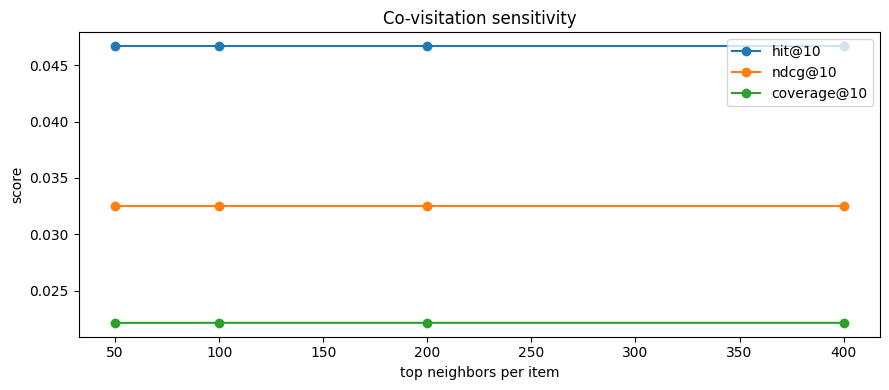

In [14]:
covisit_results_dataframe[
    [f"hit@{evaluation_k}", f"ndcg@{evaluation_k}", f"coverage@{evaluation_k}"]
].plot(marker="o")
plt.title("Co-visitation sensitivity")
plt.xlabel("top neighbors per item")
plt.ylabel("score")
plt.tight_layout()
plt.show()

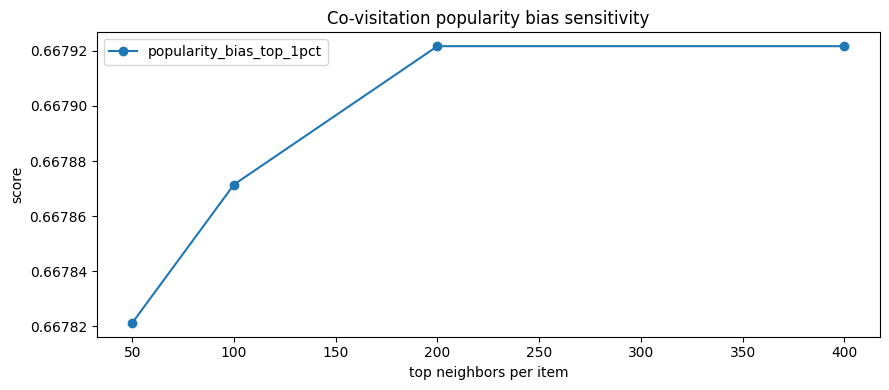

In [15]:
covisit_results_dataframe[["popularity_bias_top_1pct"]].plot(marker="o")
plt.title("Co-visitation popularity bias sensitivity")
plt.xlabel("top neighbors per item")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [16]:
summary_rows = []

best_als_hit = factor_results_dataframe[f"hit@{evaluation_k}"].idxmax()
best_als_ndcg = factor_results_dataframe[f"ndcg@{evaluation_k}"].idxmax()

best_covisit_hit = covisit_results_dataframe[f"hit@{evaluation_k}"].idxmax()
best_covisit_ndcg = covisit_results_dataframe[f"ndcg@{evaluation_k}"].idxmax()

summary_rows.append({"criterion": f"best ALS hit@{evaluation_k}", "value": int(best_als_hit)})
summary_rows.append({"criterion": f"best ALS ndcg@{evaluation_k}", "value": int(best_als_ndcg)})
summary_rows.append({"criterion": f"best covisit hit@{evaluation_k}", "value": int(best_covisit_hit)})
summary_rows.append({"criterion": f"best covisit ndcg@{evaluation_k}", "value": int(best_covisit_ndcg)})

pd.DataFrame(summary_rows)

,criterion,value
0,best ALS hit@10,64
1,best ALS ndcg@10,64
2,best covisit hit@10,50
3,best covisit ndcg@10,50


The global popularity baseline performs very poorly for the cart-oriented next-item recommendation task and is fully dominated by both ALS and co-visitation.
ALS achieves the best ranking quality, while co-visitation improves catalog coverage.
Among ALS configurations, 64 latent factors give the best Hit@10 and NDCG@10, but also introduce extreme popularity bias.
ALS with 128 factors provides a much better trade-off between ranking quality and recommendation diversity, and is therefore selected as the main baseline.
Co-visitation remains a strong complementary model and is a good candidate for hybridization.